# Boolean models

In [4]:
# === PARAMETERS ===
model_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Bonesis_13/model.bnet"
attractor_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Bonesis_13/attractors.csv"  # Attractors vectors
data_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Bonesis_13/data_binarized_tf_gene_sep.csv"  # Final states vectors
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"

In [5]:
import sys
import json
import scanpy as sc
import numpy as np
import pandas as pd
import gc
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import bonesis
import pyreadr
import ast
import seaborn as sns
import matplotlib.patches as mpatches
import mpbn

## 1) Extract the attractors from the model .bnet and the phenotype from the data

In [6]:
mbn = mpbn.MPBooleanNetwork(model_file)
count = mbn.count_attractors(reachable_from=None)
iterator = mbn.attractors(reachable_from=None)
print(count)
attra = list(iterator)
# DataFrame
attractors = pd.DataFrame(attra)
attractors = attractors[sorted(attractors.columns)]
# Row names
attractors.index = [f"Attractor{i+1}" for i in range(len(attractors))]
attractors.index.name = "Attractor"

4


In [3]:
attractors = pd.read_csv(attractor_file,index_col=0)
print(attractors.shape)
attractors.head()

(4, 579)


,ABCA1,ABCB1,ABI3,ACOT7,ACP5,ACYP2,ADAM19,ADAM9,ADSL,AIFM2,AK1,AKAP12,ALDH1A1,ALDH2,ALOX5,ANAPC15,ANK2,ANXA1,ANXA2,ANXA5,APEX1,APOC2,APOD,APOE,APRT,ARHGDIA,ARHGDIB,ARL4C,ARRB2,ARRDC3,ATF3,ATF4,ATF5,ATF6,ATF7IP,ATG4A,ATOX1,ATP2A3,ATP8A1,AURKAIP1,AUTS2,B4GALT1,BANF1,BATF,BCAS3,BCAT1,BCL2A1,BCL6,BHLHE41,BID,BIRC3,BLMH,BLOC1S1,BLVRA,BNIP3L,BRCA2,BSG,BTG3,C1QA,C1QB,C1QBP,CA3,CACNB2,CALR,CAMK1D,CAPG,CASP1,CASP4,CAT,CBLB,CCL13,CCL2,CCL3,CCL4,CCL8,CCND2,CCR6,CCT6A,CD14,CD24,CD27,CD38,CD40,CD59,CD63,CD68,CD83,CD9,CDA,CDC25B,CDK2AP1,CDK5,CDKN1A,CDKN1C,CEBPA,CEBPB,CEBPD,CEBPG,CERK,CHI3L1,CHRNB1,CIITA,CKS2,CLASRP,CLEC7A,CLOCK,CNR1,COL4A3,COMMD7,COX17,COX5B,COX6A1,CRABP2,CREB1,CREB5,CREG1,CRTC1,CRY1,CST3,CSTA,CSTB,CTSB,CTSC,CTSD,CTSL,CUBN,CUX1,CXCL10,CXCL8,CXCL9,CXCR3,CXCR4,CXXC5,CYBB,CYBRD1,CYCS,CYP1B1,CYP27A1,CYSLTR1,DAB1,DAB2,DAPK2,DBI,DCSTAMP,DCTN6,DDAH1,DDB2,DDIT3,DDIT4,DDT,DDX60L,DGKG,DHRS3,DIAPH2,DNAJC1,DNASE2,DNPH1,DRAM2,DSTN,E2F4,EFHC1,EFHD2,EGR1,EGR2,EIF4A1,EIF4EBP1,EIF5A,ELL2,EMP1,ENO1,ENPP2,EPB41,EPB41L3,EPSTI1,ERAP2,ESR1,ESR2,ETF1,ETS1,EXT1,F13A1,F5,FABP3,FABP5,FASTK,FBP1,FCER1G,FCGR1A,FCGR3A,FCRL1,FCRL5,FER,FGL2,FHIT,FKBP4,FLCN,FN1,FNDC3B,FOS,FOXO1,FRMD5,FYB1,GAPDH,GATA3,GATM,GCHFR,GLIPR1,GLRX,GLUL,GPNMB,GPX4,GRIN2B,GSN,GUCY2C,HAMP,HCK,HERC5,HERPUD1,HIF1A,HIP1,HIVEP1,HMBS,HMGA1,HNMT,HOXA1,HS1BP3,HS2ST1,HSPA5,HSPA8,HSPB1,HSPD1,HSPE1,ICOS,IER2,IER3,IER5,IFI27,IFI30,IFI6,IFIT1,IFIT2,IFIT3,IFITM3,IKZF2,IL10RA,IL15,IL18,IL1RN,IL2RA,IL2RB,IL32,IL3RA,IL4R,IL7,IMPACT,IMPDH1,IMPDH2,IRAK2,IRF1,IRF4,ITGB2,ITGB7,JPT1,JUNB,JUND,KANK1,KAT2B,KCNC1,KCND2,KCNMA1,KCNQ5,KDM3A,KDM7A,KLF1,KLF12,KLF13,KLF2,KPNA2,L1TD1,LAT2,LCN8,LDHA,LDHB,LEF1,LEPR,LGALS1,LGALS3,LILRB1,LILRB4,LMO2,LRRC59,LTB,LYRM4,LYZ,MAFB,MAML2,MAP2,MAP2K1,MAP3K1,MAP3K11,MAP3K8,MAPK8,MAPKAPK3,MARCKS,MATK,MAZ,MBTPS2,MCU,ME1,MECP2,MEF2A,MGLL,MITF,MLLT3,MMP9,MNDA,MRC1,MRPL17,MRPL21,MRPL27,MRPL41,MRPS24,MSR1,MT1E,MT1F,MT2A,MTHFD1L,MTHFD2,MTSS1,MTX1,MX1,MX2,MXD1,MXI1,MYBL2,MYC,MYCN,MYO1E,MYOD1,MYOM1,NAMPT,NCF2,NCF4,NDRG1,NDUFA6,NDUFAF2,NDUFAF3,NEK6,NEO1,NFE2L2,NFKBIA,NFKBIB,NINJ1,NME1,NME2,NOTCH2,NR1D2,NR1H3,NR1I2,NRIP1,NUPR1,NUTF2,NXT1,ODC1,ONECUT1,PABPC4,PAPSS1,PATJ,PCBD1,PDE7B,PDGFD,PDIA6,PDLIM7,PEA15,PEG10,PEPD,PGD,PHB2,PIGR,PIK3CA,PKIB,PKM,PLA2G7,PLAAT4,PLAC8,PLAGL1,PLAUR,PLCG2,PLEK,PLSCR1,PML,PMVK,PNP,POU2AF1,POU2F1,PPA1,PPDPF,PPIF,PPP1R15A,PPP1R7,PRDX1,PRDX3,PRDX5,PRKCE,PRKN,PROCR,PRXL2A,PSAP,PSMA4,PSMA6,PSMB5,PSMB6,PSMC2,PSMC5,PSMD11,PSMG1,PTGDS,PTH2R,PTPN11,PTPRG,PTTG1,PUF60,PYCARD,RAB13,RAB20,RAB31,RAB34,RAC1,RARB,RASGEF1B,RBM3,RBP1,RBPJ,RCAN1,RELA,RELB,RGCC,RGS10,RGS2,RHOC,RNASE1,RNF14,RNF144B,RNH1,ROR1,RORA,RPS6KA5,S100A10,S100A11,S100A13,S100A4,S100A8,S100A9,SAMD7,SAMD9L,SAMHD1,SARS2,SAT1,SCD,SCFD2,SDC2,SDCBP,SELENOH,SELENOP,SELENOS,SELL,SELP,SELPLG,SEMA4B,SERP1,SERPINA1,SERPINF1,SESN3,SFMBT1,SFTPB,SGK1,SGK3,SH3BP2,SHMT2,SLAMF7,SLC14A1,SLC1A5,SLC25A19,SLC25A3,SLC25A5,SLC2A13,SLC3A2,SLC7A5,SMS,SMYD3,SNRPB,SOD2,SOX2,SP1,SPI1,SPOCK2,SPP1,SRGN,SRM,SSBP3,ST3GAL5,ST6GALNAC3,SUB1,SUMO3,SUPT3H,SURF2,SYNGR2,TACR1,TAF10,TAF4B,TAF9,TAL1,TALDO1,TBP,TESK1,TFEC,TFPT,TFRC,THOP1,TIGAR,TIMP1,TKT,TMEM126A,TNFAIP2,TNFRSF18,TNFRSF4,TNFSF10,TNFSF12,TNFSF13,TNFSF13B,TP53,TPD52,TPI1,TPK1,TPM2,TRIAP1,TRIB3,TRIM14,TRIM22,TRIP6,TRPS1,TSC22D3,TSFM,TSPO,TTN,TUBA1B,TUBB,TUBG1,TXN,TXN2,TXNIP,TYMP,TYROBP,UBE2S,UCHL3,UCK2,UGDH,UPP1,UQCRC1,UQCRQ,UROS,UST,UTRN,UTY,VAV3,VDAC1,VEGFB,VIPR1,WDFY4,WT1,WWOX,XAF1,XBP1,XRN1,YWHAG,ZEB1,ZNF569,ZNF611,ZNRF2
Attractor,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [20]:
data = pd.read_csv(data_file,index_col=0)
print(data.shape)
data.head()

(4, 2632)


AAMDC  ABCA1  ABCA10  ABCA5  ABCA9  ABCB1  ABCB4  ABCC5  ABCD2  \
macrostate                                                                   
S0            NaN    NaN     1.0    NaN    1.0    1.0    NaN    NaN    1.0   
S11           1.0    1.0     NaN    NaN    NaN    1.0    1.0    NaN    NaN   
S2            0.0    NaN     0.0    0.0    0.0    0.0    0.0    0.0    NaN   
S3            0.0    0.0     0.0    NaN    NaN    0.0    0.0    NaN    0.0   

            ABCD3  ABCF1  ABCG1  ABHD18  ABHD3  ABHD5  ABI2  ABI3  ABL1  ABL2  \
macrostate                                                                      
S0            1.0    NaN    NaN     1.0    1.0    NaN   NaN   NaN   1.0   1.0   
S11           NaN    0.0    NaN     NaN    NaN    NaN   NaN   NaN   NaN   NaN   
S2            0.0    0.0    NaN     0.0    NaN    NaN   0.0   1.0   NaN   0.0   
S3            NaN    1.0    0.0     NaN    0.0    1.0   NaN   0.0   NaN   NaN   

            ABR  ABRACL  ACACA  ACAD11  ACADSB  ACBD6  ACER2  ACMSD  ACO1  \
macrostate                                                                  
S0          1.0     0.0    NaN     1.0     NaN    NaN    NaN    1.0   NaN   
S11         1.0     0.0    0.0     NaN     NaN    NaN    NaN    NaN   NaN   
S2          0.0     0.0    0.0     0.0     0.0    0.0    0.0    NaN   NaN   
S3          0.0     1.0    NaN     NaN     NaN    NaN    NaN    NaN   0.0   

            ACOT7  ACOXL  ACP5  ACP6  ACSL1  ACSM1  ACSM3  ACSM6  ACTG1  \
macrostate                                                                
S0            NaN    NaN   NaN   1.0    NaN    1.0    1.0    1.0    0.0   
S11           0.0    0.0   0.0   NaN    0.0    1.0    1.0    NaN    0.0   
S2            NaN    0.0   NaN   NaN    NaN    0.0    0.0    0.0    NaN   
S3            1.0    1.0   0.0   NaN    1.0    0.0    0.0    NaN    1.0   

            ACTR3B  ACTR3C  ACTR6  ACVR1  ACVR2A  ACYP2  ADA2  ADAM10  ADAM19  \
macrostate                                                                      
S0             NaN     1.0    NaN    1.0     1.0    1.0   1.0     NaN     1.0   
S11            NaN     NaN    0.0    0.0     NaN    NaN   1.0     1.0     NaN   
S2             0.0     0.0    0.0    NaN     0.0    0.0   0.0     0.0     NaN   
S3             NaN     NaN    NaN    NaN     NaN    0.0   0.0     0.0     0.0   

            ADAM28  ADAM9  ADAMDEC1  ADAMTS6  ADARB1  ADD3  ADGRF3  ADHFE1  \
macrostate                                                                   
S0             1.0    NaN       0.0      1.0     NaN   1.0     1.0     1.0   
S11            1.0    0.0       NaN      NaN     NaN   1.0     NaN     NaN   
S2             0.0    NaN       1.0      0.0     NaN   0.0     NaN     NaN   
S3             0.0    1.0       NaN      0.0     1.0   0.0     NaN     0.0   

            ADK  ADTRP  AEBP1  AEBP2  AFF1  AFG1L  AGA  AGBL2  AGBL3  AGBL5  \
macrostate                                                                    
S0          NaN    1.0    NaN    1.0   1.0    1.0  NaN    NaN    1.0    NaN   
S11         NaN    1.0    NaN    NaN   NaN    NaN  NaN    NaN    NaN    NaN   
S2          0.0    0.0    NaN    0.0   0.0    0.0  NaN    NaN    0.0    0.0   
S3          NaN    0.0    0.0    0.0   0.0    NaN  1.0    0.0    NaN    NaN   

            AGK  AGO3  AGO4  AGPAT4  AGPAT5  AGTPBP1  AGTRAP  AHCYL2  AHI1  \
macrostate                                                                   
S0          NaN   1.0   1.0     1.0     1.0      1.0     NaN     1.0   1.0   
S11         NaN   1.0   NaN     NaN     1.0      NaN     0.0     NaN   NaN   
S2          0.0   0.0   NaN     NaN     0.0      0.0     NaN     0.0   0.0   
S3          NaN   0.0   0.0     0.0     1.0      NaN     NaN     NaN   NaN   

            AHNAK  AHR  AIF1  AIFM1  AIG1  AK1  AK6  AK9  AKAP12  AKAP7  \
macrostate                                                                
S0            1.0  NaN   0.0    NaN   NaN  NaN  0.0  1.0     NaN    NaN   
S11           NaN

In [11]:
# Common genes
common_genes = attractors.columns.intersection(data.columns)

# Subset
attractors = attractors[common_genes]
data = data[common_genes]

print(f"Commons genes : {len(common_genes)}")
print("Attractors :", attractors.shape)
print("Data       :", data.shape)

Commons genes : 445
Attractors : (4, 445)
Data       : (4, 445)


## 3) Evaluate the attractors

### Patterns 

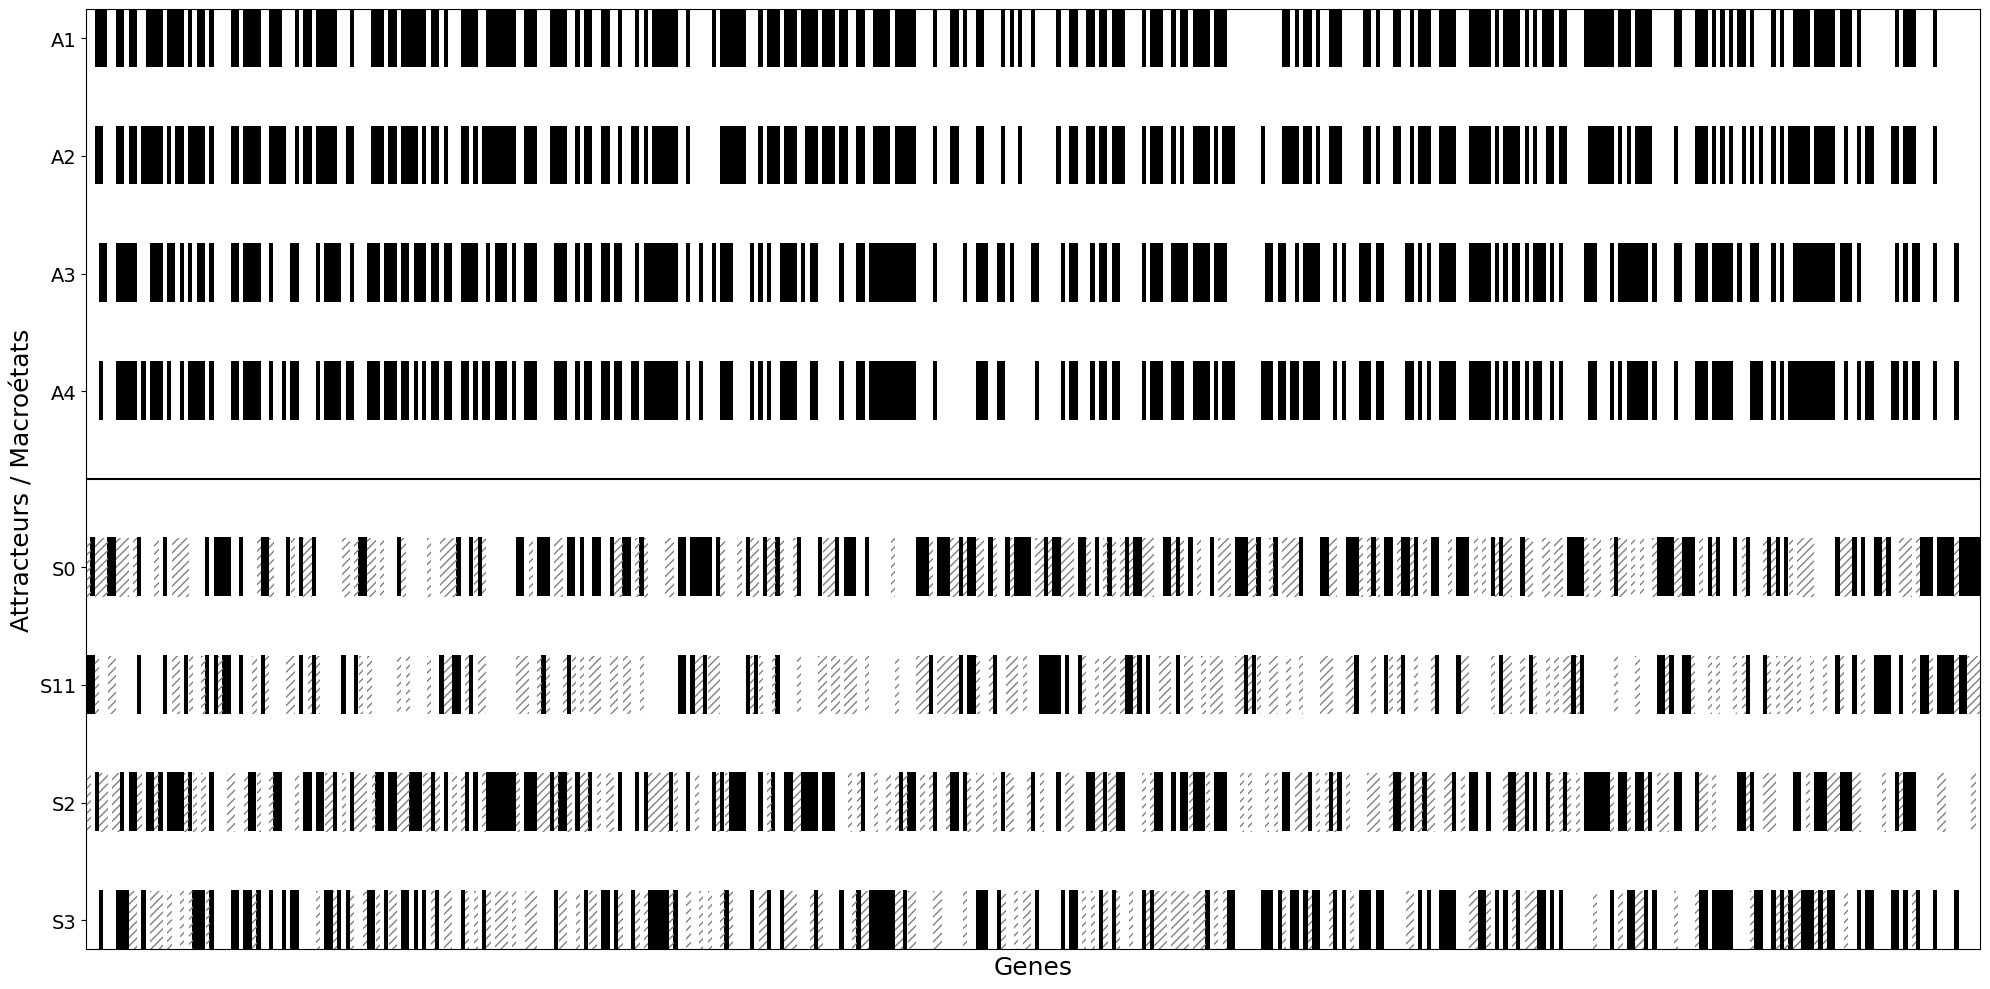

In [9]:
# Commons genes 
common_genes = [g for g in attractors.columns if g in data.columns]

df_common = attractors[common_genes]
data_common = data[common_genes]

mat1 = df_common.values
mat2 = data_common.values

n_rows1, n_cols = mat1.shape
n_rows2, _ = mat2.shape

# Space between matrix 
def space_matrix(mat):
    n_rows, n_cols = mat.shape
    spaced = np.full((n_rows * 2 - 1, n_cols), np.nan)pourcentage de gènes identiques
    spaced[::2] = mat
    return spaced

mat1_spaced = space_matrix(mat1)
mat2_spaced = space_matrix(mat2)

# Space between matrix 
gap = 2
sep = np.full((gap, n_cols), np.nan)

full_mat = np.vstack([mat1_spaced, sep, mat2_spaced])

# Mask for Nan
real_data_mask = np.zeros_like(full_mat, dtype=bool)
real_data_mask[0:mat1_spaced.shape[0]:2, :] = True
offset = mat1_spaced.shape[0] + gap
real_data_mask[offset::2, :] = True

nan_to_hatch = np.isnan(full_mat) & real_data_mask

# Colormap
cmap = plt.cm.binary.copy()
cmap.set_bad(color="white", alpha=0)

fig, ax = plt.subplots(figsize=(20, 10))

ax.imshow(
    full_mat,
    cmap=cmap,
    aspect="auto",
    interpolation="none",
    vmin=0, vmax=1)

for i in range(full_mat.shape[0]):
    for j in range(full_mat.shape[1]):
        if nan_to_hatch[i, j]:
            ax.add_patch(mpatches.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                facecolor="none",
                edgecolor="grey",
                hatch="////",
                linewidth=0
            ))

#Ticks
yticks_pos = list(range(0, mat1_spaced.shape[0], 2)) + \
             [offset + i for i in range(0, mat2_spaced.shape[0], 2)]
yticks_labels = [f"A{i+1}" for i in range(n_rows1)] + list(data_common.index)
ax.set_yticks(yticks_pos)
ax.set_yticklabels(yticks_labels, fontsize=14)
ax.axhline(mat1_spaced.shape[0] + gap / 2 - 0.5, color="black", linewidth=1.5)
ax.set_xticks([])
ax.set_xlabel("Genes", fontsize=18)
ax.set_ylabel("Attractors / Macrostates", fontsize=18)
plt.tight_layout()
plt.show()

### Similarity matrix 

With the Nan (NaN = false) 

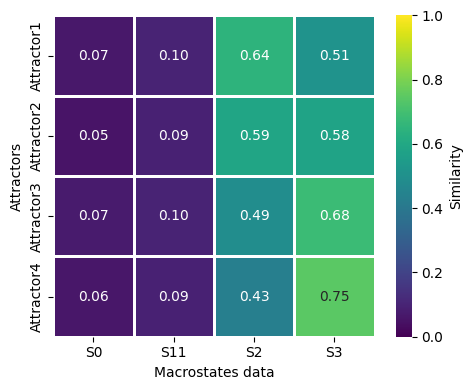

In [31]:
similarity = pd.DataFrame(
    index=attractors.index,
    columns=data.index,
    dtype=float)

for attr_name, attr_row in attractors.iterrows():
    for data_name, data_row in data.iterrows():
        similarity.loc[attr_name, data_name] = np.mean(
            attr_row.values == data_row.values)

print(similarity)
plt.figure(figsize=(5,4))
sns.heatmap(similarity,annot=True,cmap="viridis",vmin=0,vmax=1,square=True,linewidths=1,fmt=".2f",cbar_kws={"label": "Similarity"})
plt.xlabel("Macrostates data")
plt.ylabel("Attractors")
plt.tight_layout()
plt.show()

Keep only gene without Nan per macrostates 

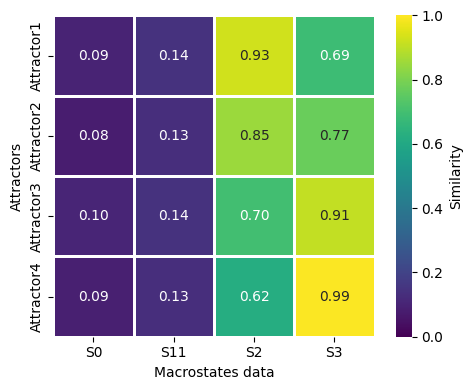

In [11]:
similarity = pd.DataFrame(
    index=attractors.index,
    columns=data.index,
    dtype=float)

for attr_name, attr_row in attractors.iterrows():
    for data_name, data_row in data.iterrows():
        mask = ~pd.isna(data_row.values)
        similarity.loc[attr_name, data_name] = np.mean(
            attr_row.values[mask] == data_row.values[mask]
        )
        
plt.figure(figsize=(5,4))
sns.heatmap(similarity,annot=True,cmap="viridis",vmin=0,vmax=1,square=True,linewidths=1,fmt=".2f",cbar_kws={"label": "Similarity"})
plt.xlabel("Macrostates data")
plt.ylabel("Attractors")
plt.tight_layout()
plt.show()

Dotplot (same than the similarity matrix, but with the size, number of genes) 

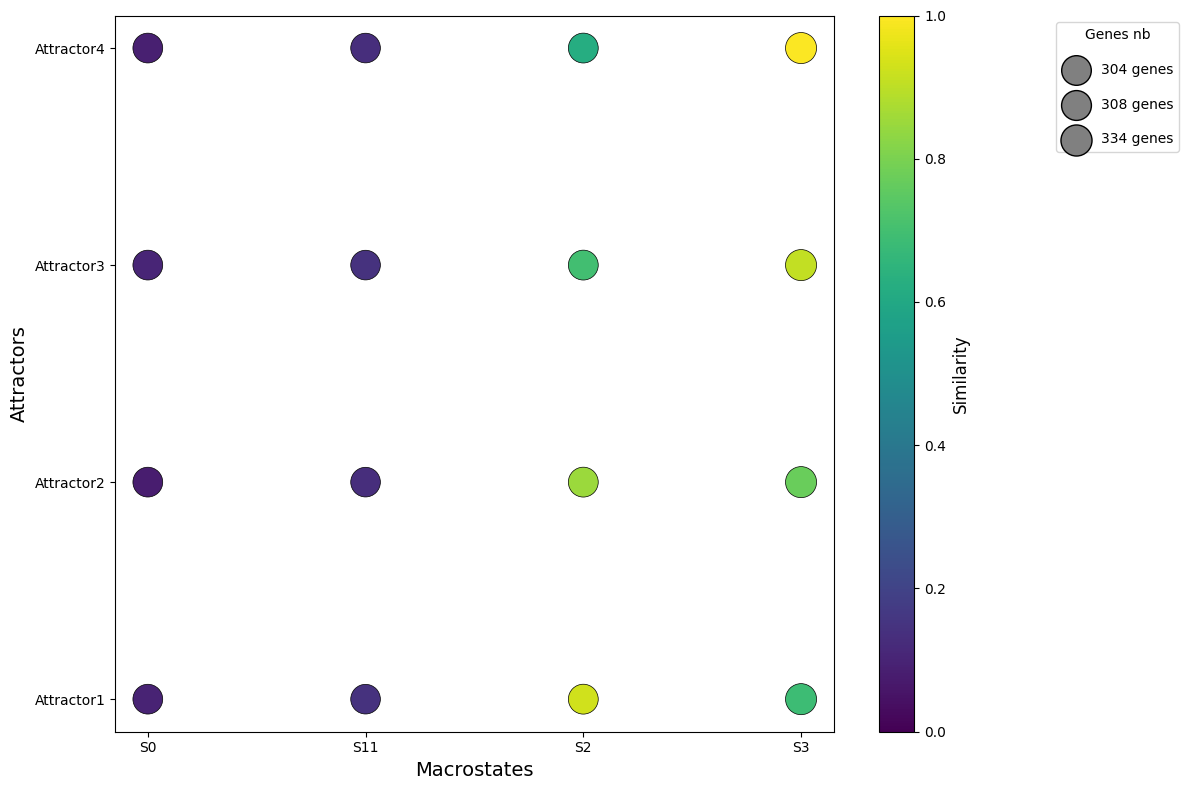

In [15]:
similarity = pd.DataFrame(
    index=attractors.index,
    columns=data.index,
    dtype=float)

n_genes_used = pd.DataFrame(index=attractors.index, columns=data.index, dtype=int)

for attr_name, attr_row in attractors.iterrows():
    for data_name, data_row in data.iterrows():
        mask = ~pd.isna(data_row.values)
        similarity.loc[attr_name, data_name] = np.mean(
            attr_row.values[mask] == data_row.values[mask])
        n_genes_used.loc[attr_name, data_name] = mask.sum()

attr_names = similarity.index
data_names = similarity.columns

xs, ys, sizes, colors = [], [], [], []

for i, attr_name in enumerate(attr_names):
    for j, data_name in enumerate(data_names):
        xs.append(j)
        ys.append(i)
        colors.append(similarity.loc[attr_name, data_name])
        sizes.append(n_genes_used.loc[attr_name, data_name])

sizes = np.array(sizes, dtype=float)
sizes_scaled = (sizes / sizes.max()) * 500

#dotplot
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    xs, ys,
    s=sizes_scaled,
    c=colors,
    cmap="viridis",
    vmin=0, vmax=1,
    edgecolors="black",
    linewidths=0.5)

# Ticks and labels
ax.set_xticks(range(len(data_names)))
ax.set_xticklabels(data_names, rotation=0, fontsize=10)
ax.set_yticks(range(len(attr_names)))
ax.set_yticklabels(attr_names, fontsize=10)

ax.set_xlabel("Macrostates", fontsize=14)
ax.set_ylabel("Attractors", fontsize=14)

#Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Similarity", fontsize=12)

# Legend
for n in [sizes.min(), np.median(sizes), sizes.max()]:
    plt.scatter([], [], s=(n / sizes.max()) * 500, c="grey", edgecolors="black", label=f"{int(n)} genes")
plt.legend(scatterpoints=1, frameon=True, labelspacing=1.5, title="Genes nb", bbox_to_anchor=(1.3, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Reachability 

In [32]:
# Network
bn = mpbn.MPBooleanNetwork(model_file)

# Macrostates
df = pd.read_csv(data_file, index_col=0)
macrostates = {}

for name, row in df.iterrows():
    state = {}
    for gene, value in row.items():
        if pd.isna(value):
            continue
        if value == "*":
            continue
        state[gene] = int(value)
    macrostates[name] = state

# Matrix calcul
reach = pd.DataFrame(
    0,
    index=macrostates.keys(),
    columns=macrostates.keys())

for source_name, source in macrostates.items():
    for target_name, target in macrostates.items():

        if bn.reachability(source, target):
            reach.loc[source_name, target_name] = 1

print(reach)

     S0  S11  S2  S3
S0    1    0   0   0
S11   0    1   0   0
S2    0    0   1   0
S3    0    0   0   1


Transition probability matrix 

In [ ]:
if "TP53" not in init:
    print("TP53 absent !")
    print(init.keys())
    break

In [ ]:
import mpbn.simulation as mpsim

N_RANDOM_STATES = 1000
N_SIMULATIONS = 500
transition_matrix = np.zeros((len(data),len(attractors)))

def sample_state(macrostate):
    state = {}
    for gene, value in macrostate.items():
        if pd.isna(value):
            state[gene] = np.random.randint(2)
        else:
            state[gene] = int(value)
    return state

for i, (_, macro) in enumerate(data.iterrows()):
    print(f"Macrostate {i+1}")
    probs_macro = np.zeros(len(attractors))
    for _ in range(N_RANDOM_STATES):
        init = sample_state(macro)
        reachable = list(mbn.attractors(reachable_from=init))

        probs = mpsim.parallel_estimate_reachable_attractors_probabilities(
            mbn,
            init,
            reachable,
            N_SIMULATIONS,
            depth=mpsim.nexponential_depth(mbn),
            W=mpsim.nexponential_rates(mbn),
            nb_jobs=8)

        for k, attr in enumerate(reachable):
            idx = attractors.index.get_loc(attr.name)
            probs_macro[idx] += probs.get(k,0)
    probs_macro /= N_RANDOM_STATES
    transition_matrix[i,:] = probs_macro

transition_matrix /= 100
transition_df = pd.DataFrame(
    transition_matrix,
    index=data.index,
    columns=attractors.index)

print(transition_df)

Macrostate 1


/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/mpbn/simulation.py:346: RuntimeWarning: divide by zero encountered in divide
  p = 1/ base**np.arange(0, n)
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/mpbn/simulation.py:347: RuntimeWarning: invalid value encountered in divide
  p /= p.sum()
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/mpbn/simulation.py:380: RuntimeWarning: divide by zero encountered in divide
  return 1 / base**np.arange(0, len(f))
Process Process-9:
Traceback (most recent call last):
Process Process-10:
  File "/home/a.blanc-boekholt/miniconda3/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Process Process-11:
Traceback (most recent call last):
  File "/home/a.blanc-boekholt/miniconda3/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/a.blanc-boekholt/

In [ ]:
missing = sorted(set(mbn.keys()) - set(data.columns))

print(f"{len(missing)} gènes du réseau sont absents des macrostates.")
print(missing[:20])   # affiche les 20 premiers

In [19]:
print(data.shape)
print(attractors.shape)

(4, 445)
(4, 445)


### UMAP